# 2021 CDC Natality Data

Every year, millions of babies are born in the United States. Anonymized data surrounding each birth is collected by the CDC and made available to the public. Here we will explore that data.

### Common Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# suppress warnings
import warnings

warnings.filterwarnings("ignore")

### 1. Load Data

In [4]:
df = pd.read_parquet("../../data/processed/natality_2021_cleaned.parquet")

In [15]:
head = df.head()

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3669928 entries, 0 to 3669927
Columns: 139 entries, birth_month to infant_breastfed_at_discharge
dtypes: float64(52), int64(87)
memory usage: 3.8 GB


### 2. Univariate Visualizations

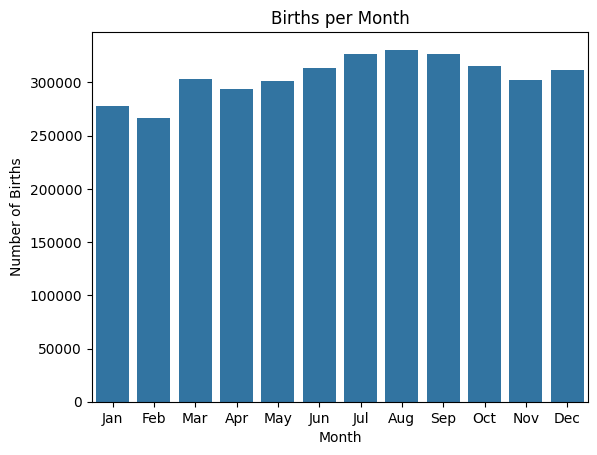

In [75]:
births_per_month_histogram_ax = sns.barplot(
    x=[
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
        "Oct",
        "Nov",
        "Dec",
    ],
    y=df["birth_month"].value_counts(sort=False),
)
births_per_month_histogram_ax.set_title("Births per Month")
births_per_month_histogram_ax.set_xlabel("Month")
births_per_month_histogram_ax.set_ylabel("Number of Births")

plt.show()

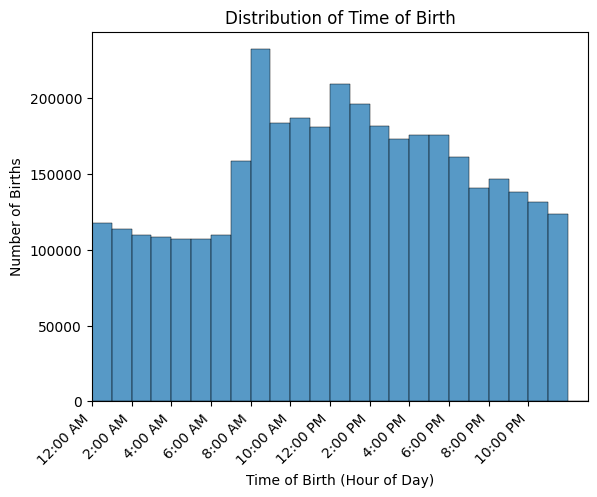

In [8]:
time_of_birth_histogram_ax = sns.histplot(df["time_of_birth"], bins=60, binwidth=100)
time_of_birth_histogram_ax.set_xlim(0, 2500)
time_of_birth_histogram_ax.set_xticks(np.arange(0, 2300, 200))
time_of_birth_histogram_ax.set_xticklabels(
    [
        "12:00 AM",
        "2:00 AM",
        "4:00 AM",
        "6:00 AM",
        "8:00 AM",
        "10:00 AM",
        "12:00 PM",
        "2:00 PM",
        "4:00 PM",
        "6:00 PM",
        "8:00 PM",
        "10:00 PM",
    ],
    rotation=45,
    horizontalalignment="right",
)
time_of_birth_histogram_ax.set
time_of_birth_histogram_ax.set_title("Distribution of Time of Birth")
time_of_birth_histogram_ax.set_xlabel("Time of Birth (Hour of Day)")
time_of_birth_histogram_ax.set_ylabel("Number of Births")

plt.show()

Text(0, 0.5, 'Number of Births')

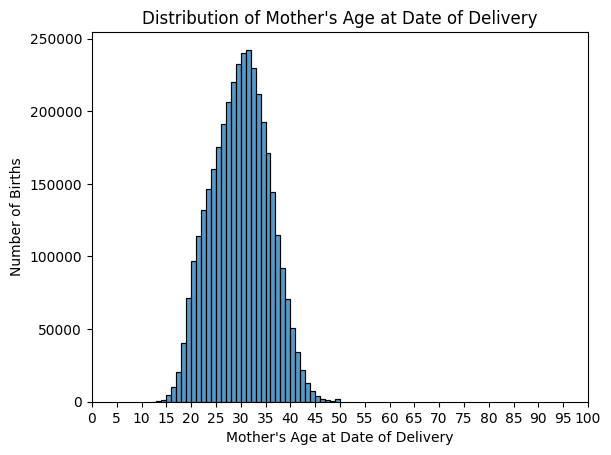

In [ ]:
mothers_single_year_age_value_counts = df["mothers_single_year_age"].value_counts(
    sort=False
)

mothers_age_histogram_ax = sns.histplot(
    x=mothers_single_year_age_value_counts.index,
    weights=mothers_single_year_age_value_counts.values,
    binwidth=1,
)
mothers_age_histogram_ax.set_title("Distribution of Mother's Age at Date of Delivery")
mothers_age_histogram_ax.set_xlim(0)
mothers_age_histogram_ax.set_xticks(np.arange(0, 101, 5))
mothers_age_histogram_ax.set_xlabel("Mother's Age at Date of Delivery")
mothers_age_histogram_ax.set_ylabel("Number of Births")

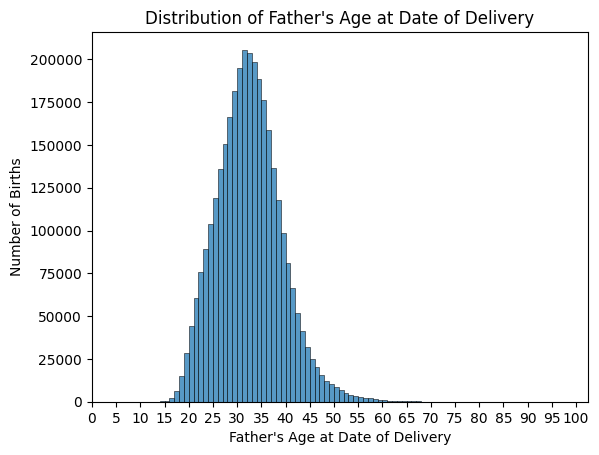

In [ ]:
fathers_combined_age_value_counts = df["fathers_combined_age"].value_counts(sort=False)
fathers_combined_age_value_counts = fathers_combined_age_value_counts.drop(99)

fathers_age_histogram_ax = sns.histplot(
    x=fathers_combined_age_value_counts.index,
    weights=fathers_combined_age_value_counts.values,
    binwidth=1,
)
fathers_age_histogram_ax.set_title("Distribution of Father's Age at Date of Delivery")
fathers_age_histogram_ax.set_xlim(0)
fathers_age_histogram_ax.set_xticks(np.arange(0, 101, 5))
fathers_age_histogram_ax.set_xlabel("Father's Age at Date of Delivery")
fathers_age_histogram_ax.set_ylabel("Number of Births")

plt.show()

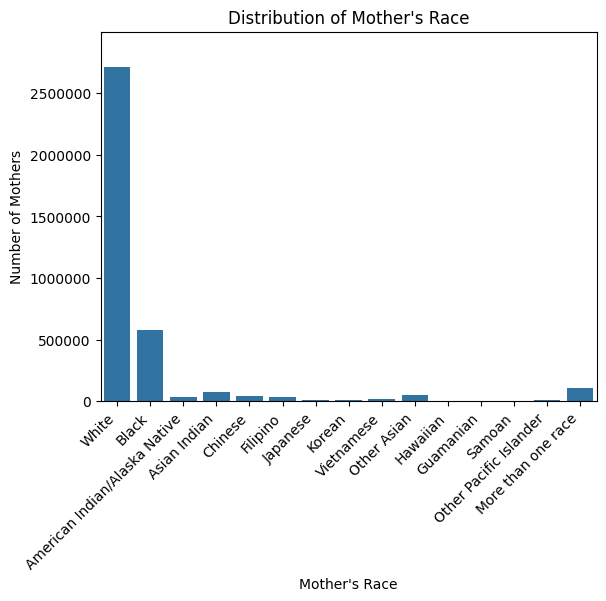

In [ ]:
mothers_race_15_value_counts = df["mothers_race_recode_15"].value_counts()


mothers_race_bar_chart_ax = sns.barplot(
    x=mothers_race_15_value_counts.index, y=mothers_race_15_value_counts.values
)
mothers_race_bar_chart_ax.set_title("Distribution of Mother's Race")
mothers_race_bar_chart_ax.set_ylabel("Number of Mothers")
mothers_race_bar_chart_ax.set_yticks(
    np.arange(0, 3000000, 500000), labels=np.arange(0, 3000000, 500000)
)
mothers_race_bar_chart_ax.set_ylim(0, 3000000)
mothers_race_bar_chart_ax.set_xlabel("Mother's Race")
mothers_race_bar_chart_ax.set_xticklabels(
    [
        "White",
        "Black",
        "American Indian/Alaska Native",
        "Asian Indian",
        "Chinese",
        "Filipino",
        "Japanese",
        "Korean",
        "Vietnamese",
        "Other Asian",
        "Hawaiian",
        "Guamanian",
        "Samoan",
        "Other Pacific Islander",
        "More than one race",
    ],
    rotation=45,
    horizontalalignment="right",
)

plt.show()

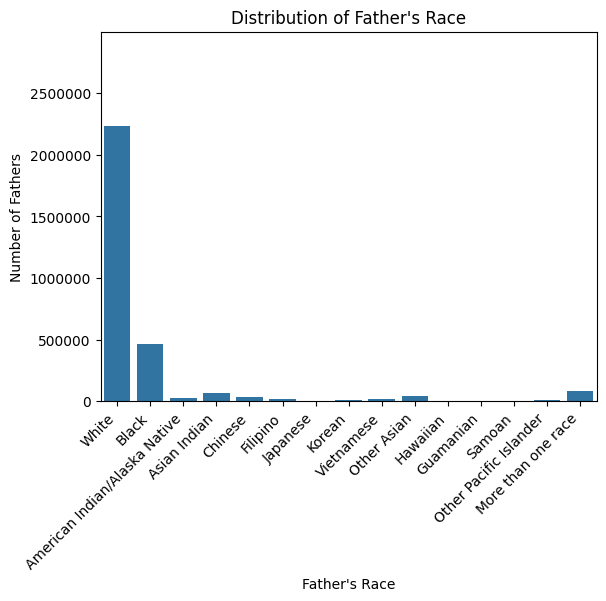

In [80]:
fathers_race_15_value_counts = df["fathers_race_recode_15"].value_counts()
fathers_race_15_value_counts = fathers_race_15_value_counts.drop(99)

fathers_race_bar_chart_ax = sns.barplot(
    x=fathers_race_15_value_counts.index, y=fathers_race_15_value_counts.values
)
fathers_race_bar_chart_ax.set_title("Distribution of Father's Race")
fathers_race_bar_chart_ax.set_ylabel("Number of Fathers")
fathers_race_bar_chart_ax.set_yticks(
    np.arange(0, 3000000, 500000), labels=np.arange(0, 3000000, 500000)
)
fathers_race_bar_chart_ax.set_ylim(0, 3000000)
fathers_race_bar_chart_ax.set_xlabel("Father's Race")
fathers_race_bar_chart_ax.set_xticklabels(
    [
        "White",
        "Black",
        "American Indian/Alaska Native",
        "Asian Indian",
        "Chinese",
        "Filipino",
        "Japanese",
        "Korean",
        "Vietnamese",
        "Other Asian",
        "Hawaiian",
        "Guamanian",
        "Samoan",
        "Other Pacific Islander",
        "More than one race",
    ],
    rotation=45,
    horizontalalignment="right",
)

plt.show()

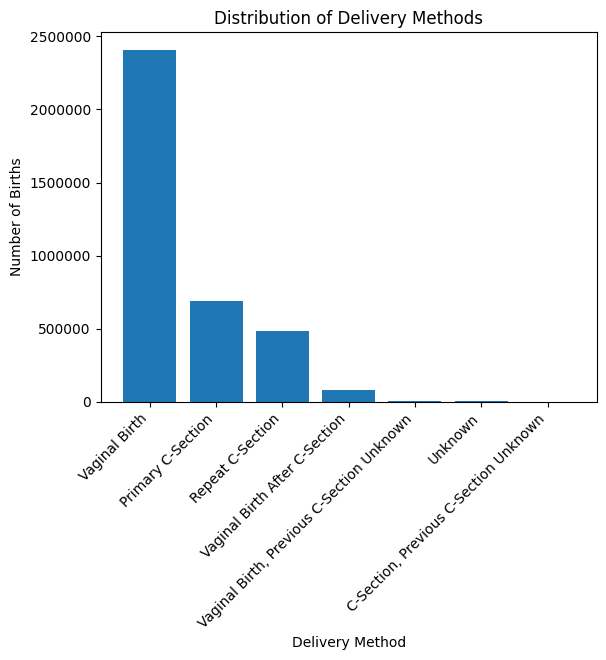

In [78]:
delivery_method_value_counts = df["delivery_method_recode_7"].value_counts()

delivery_method_value_counts_df = pd.DataFrame(delivery_method_value_counts)

delivery_method_value_counts_df = delivery_method_value_counts_df.merge(
    pd.DataFrame(
        {
            "label": [
                "Vaginal Birth",
                "Vaginal Birth After C-Section",
                "Primary C-Section",
                "Repeat C-Section",
                "Vaginal Birth, Previous C-Section Unknown",
                "C-Section, Previous C-Section Unknown",
                "Unknown",
            ],
        },
        index=[1, 2, 3, 4, 5, 6, 9],
    ),
    left_index=True,
    right_index=True,
)

_, delivery_method_value_counts_df_ax = plt.subplots()

delivery_method_value_counts_df_ax.set_title("Distribution of Delivery Methods")
delivery_method_value_counts_df_ax.set_yticklabels(np.arange(0, 3000000, 500000))
delivery_method_value_counts_df_ax.bar(
    delivery_method_value_counts_df["label"],
    delivery_method_value_counts_df["count"],
)
labels = delivery_method_value_counts_df_ax.get_xticklabels()
plt.setp(labels, rotation=45, horizontalalignment="right")
plt.xlabel("Delivery Method")
plt.ylabel("Number of Births")

plt.show()